# 01 EDA: X Ray dataset

First pass over the nine files in `data/raw`. Goals: know what each table holds, how clean
it is, how much history each company really has, and which raw signals can feed a
group-level monthly health score.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xray.data import load_all

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

BLUE, ORANGE, AQUA, YELLOW, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#898781"
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.5),
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.grid": True,
        "grid.color": "#e8e7e3",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlesize": 11,
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
    }
)

In [ ]:
T = load_all()
groups, companies = T["groups"], T["companies"]
bank, debt, sched = T["banking_products"], T["debt_products"], T["debt_schedule_config"]
tx, inv, bal = T["transactions"], T["invoices"], T["balances"]

## 1. Table overview

In [ ]:
pd.DataFrame(
    {
        "rows": {n: len(d) for n, d in T.items()},
        "cols": {n: d.shape[1] for n, d in T.items()},
        "companies": {
            n: d["company_id"].nunique() if "company_id" in d else np.nan for n, d in T.items()
        },
        "mem_mb": {n: d.memory_usage(deep=True).sum() / 1e6 for n, d in T.items()},
    }
)

,rows,cols,companies,mem_mb
groups,250,3,NaN,0.03
companies,1286,6,"1,286.00",0.34
banking_products,5987,8,"1,283.00",2.53
debt_products,2239,11,378.00,1.00
debt_schedule_config,87,14,40.00,0.04
transactions,2556437,12,"1,286.00","1,342.84"
invoices,897894,14,785.00,494.66
balances,7996,8,"1,273.00",1.34


In [ ]:
def profile(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "null_pct": df.isna().mean() * 100,
            "nunique": df.nunique(),
        }
    )


for name, df in T.items():
    print(f"\n== {name}")
    print(profile(df).to_string())


== groups
                       dtype  null_pct  nunique
group_id                 str      0.00      250
erp                      str     64.40       21
n_companies_in_sample  int64      0.00       21

== companies
                     dtype  null_pct  nunique
company_id             str      0.00     1286
group_id               str      0.00      250
country                str     82.12       22
currency               str      0.00       28
erp                    str     42.07       20
created_at  datetime64[us]      0.00     1286

== banking_products
                     dtype  null_pct  nunique
product_id             str      0.00     5987
company_id             str      0.00     1283
label                  str      0.00      143
type                   str      0.00        9
bank_name              str      0.00      200
service                str      0.00      198
currency               str      0.00       39
created_at  datetime64[us]      0.00     3699

== debt_products
        

                            dtype  null_pct  nunique
transaction_id                str      0.00  2556437
company_id                    str      0.00     1286
product_id                    str      0.00     5311
date               datetime64[us]      0.00    71456
value_date         datetime64[us]      0.00   105097
amount                    float64      0.00   763006
exchange_rate             float64      0.00     2224
status                        str      1.17        2
accounting_status             str     61.56        6
category                      str      0.01       23
description                   str      0.02   828142
counterparty_id               str     90.19    47796

== invoices


                              dtype  null_pct  nunique
operation_id                    str      0.00   897894
company_id                      str      0.00      785
document_type                   str      0.00       10
issuance_date        datetime64[us]      0.00    12704
due_date             datetime64[us]      0.00    13586
payment_date         datetime64[us]      0.00    15398
amount                      float64      0.00   318255
pending_amount              float64      0.00   115814
currency                        str      0.00       39
accounting_currency             str      0.00       23
exchange_rate               float64      0.03     1496
status                          str      0.00        7
concept                         str      0.44   562667
counterparty_id                 str      1.28   124030

== balances
                     dtype  null_pct  nunique
product_id             str      0.00     7996
company_id             str      0.00     1273
date        datetime64[u

There is **no target column** anywhere: no default flag, no health label. Whatever the hidden
test is scored against, we have to build the score from the signals themselves.

## 2. Groups and companies

count   250.00
mean      5.14
std       5.06
min       1.00
25%       1.00
50%       3.00
75%       7.00
max      22.00
groups.n_companies_in_sample matches: True


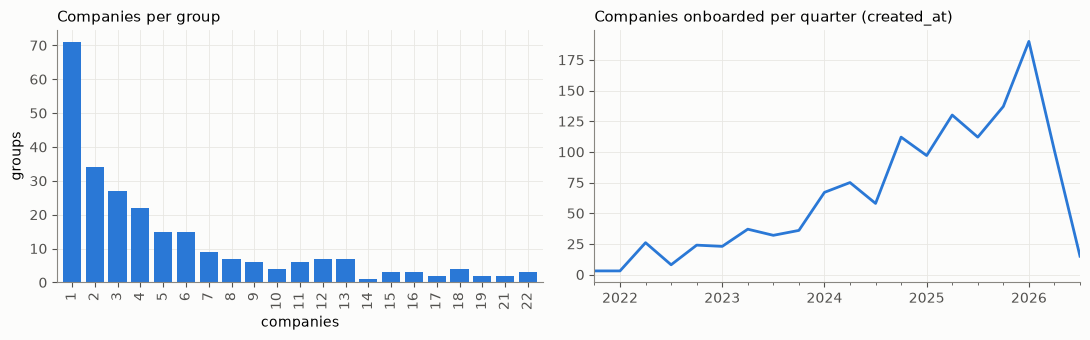

In [ ]:
size = companies.groupby("group_id").size()
print(size.describe().to_string())
print(
    "groups.n_companies_in_sample matches:",
    (groups.set_index("group_id").n_companies_in_sample == size).all(),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
size.value_counts().sort_index().plot.bar(ax=axes[0], color=BLUE, width=0.8)
axes[0].set(title="Companies per group", xlabel="companies", ylabel="groups")
companies.set_index("created_at").resample("QS").size().plot(ax=axes[1], color=BLUE, lw=2)
axes[1].set(title="Companies onboarded per quarter (created_at)", xlabel="")
plt.tight_layout()

In [ ]:
for col in ["country", "currency", "erp"]:
    print(companies[col].value_counts(dropna=False).head(8).to_string(), "\n")

country
NaN       1056
ES         142
ESPAÑA      14
NL          14
DE          11
España       9
FR           6
US           5 

currency
EUR    1149
GBP      42
USD      36
MXN       7
DKK       6
AUD       5
COP       5
PLN       4 

erp
NaN                541
businessCentral    322
netsuite           143
businessOne         47
sage200             47
dynamicsAx          42
sageX3              30
m3Rosetta           21 



`country` is 82% missing and dirty (`ES`, `ESPAÑA`, `España`): weak feature. `created_at` is
the platform onboarding date, and half of the companies were onboarded **after** the data
window starts. Does their history start at onboarding, or is it backfilled?

In [ ]:
first_tx = tx.groupby("company_id").date.min()
lag = (first_tx - companies.set_index("company_id").created_at).dt.days
print("days from created_at to first transaction:")
print(lag.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

days from created_at to first transaction:
count   1,286.00
mean       52.18
std       260.51
min      -588.00
5%       -275.00
25%       -59.00
50%       -40.00
75%       103.00
95%       656.00
max     1,096.00


## 3. Banking and debt products

companies with any debt product: 378 of 1286
groups with any debt product: 150 of 250


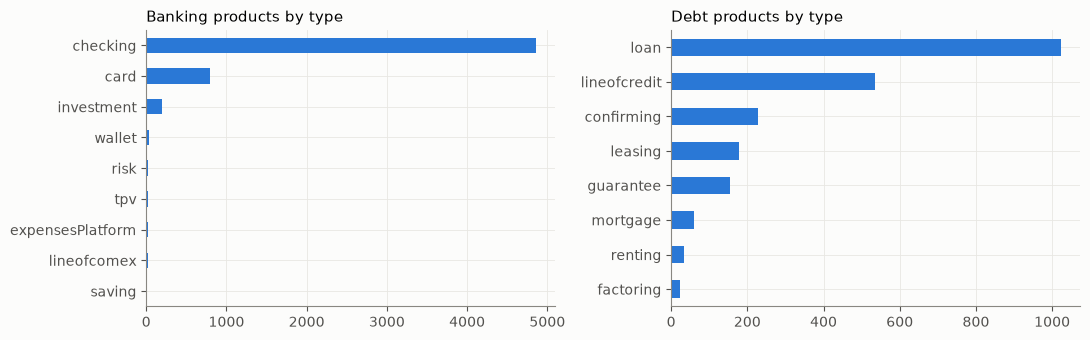

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
bank.type.value_counts().sort_values().plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title="Banking products by type", ylabel="")
debt.type.value_counts().sort_values().plot.barh(ax=axes[1], color=BLUE)
axes[1].set(title="Debt products by type", ylabel="")
plt.tight_layout()

print("companies with any debt product:", debt.company_id.nunique(), "of", len(companies))
print(
    "groups with any debt product:",
    debt.merge(companies[["company_id", "group_id"]], on="company_id").group_id.nunique(),
    "of",
    len(groups),
)

In [ ]:
# Sign convention: debt is stored negative. Positive values are the exception.
print("outstanding sign:", np.sign(debt.outstanding).value_counts().to_dict())
print("granted sign:    ", np.sign(debt.granted).value_counts(dropna=False).to_dict())
debt.groupby("type").agg(
    n=("product_id", "size"),
    granted_null=("granted", lambda s: s.isna().mean()),
    granted_median=("granted", "median"),
    outstanding_median=("outstanding", "median"),
    liquidity_null=("liquidity", lambda s: s.isna().mean()),
)

outstanding sign: {-1.0: 1351, 0.0: 743, 1.0: 145}
granted sign:     {-1.0: 2043, nan: 169, 0.0: 22, 1.0: 5}


,n,granted_null,granted_median,outstanding_median,liquidity_null
type,,,,,
confirming,229,0.23,"-900,000.00",0.00,0.24
factoring,24,0.08,"-800,000.00",0.00,0.12
guarantee,155,0.20,"-39,949.58","-39,583.00",0.86
leasing,179,0.02,"-56,159.71","-30,414.23",0.94
lineofcredit,536,0.11,"-250,000.00",-472.55,0.19
loan,1022,0.02,"-248,204.09","-35,000.00",0.86
mortgage,60,0.00,"-56,172.49","-49,590.40",1.00
renting,34,0.00,"-12,220.43","-4,057.80",0.97


utilization > 1: 0.01


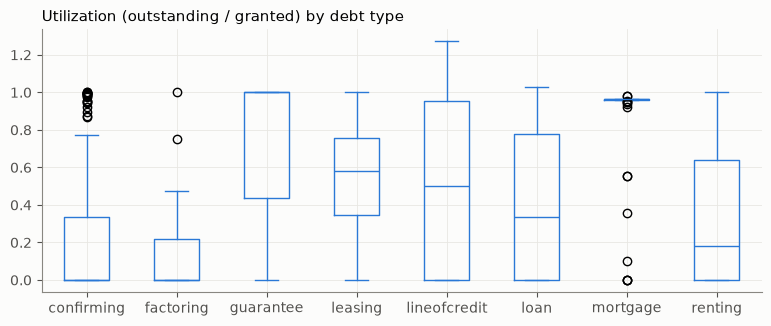

In [ ]:
# Utilization = outstanding / granted, only where both are negative and granted is known.
d = debt[(debt.granted < 0) & (debt.outstanding <= 0)].assign(
    util=lambda x: x.outstanding / x.granted
)
ax = d[d.util <= 1.5].boxplot(column="util", by="type", figsize=(9, 3.5), color=BLUE)
ax.set(title="Utilization (outstanding / granted) by debt type", xlabel="", ylabel="")
plt.suptitle("")
print("utilization > 1:", (d.util > 1).mean().round(3))

In [ ]:
print(sched.describe(include="all").T.to_string())

                               count unique             top freq                        mean                  min                         25%                  50%                         75%                  max           std
product_id                        87     87   PRODUCT_06719    1                         NaN                  NaN                         NaN                  NaN                         NaN                  NaN           NaN
company_id                        87     40       COMP_0058    9                         NaN                  NaN                         NaN                  NaN                         NaN                  NaN           NaN
settlement_product_id             87     68   PRODUCT_00935    4                         NaN                  NaN                         NaN                  NaN                         NaN                  NaN           NaN
currency                          87      1             EUR   87                         NaN    

Only 87 of 2,239 debt products have a schedule, so installments are not a general feature.
For the rest, debt service has to be read from `debt_repayment` / `interest_charge` transactions.

## 4. Transactions

date range: 2024-09-01 00:00:00 -> 2026-09-01 23:37:04


status: {'booked': 2520019, nan: 29839, 'pending': 6579}
exchange_rate != 1: 0.0395


month,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
n,"41,975.00","49,521.00","44,730.00","48,178.00","61,961.00","61,678.00","71,859.00","77,155.00","79,439.00","83,975.00","97,619.00","85,031.00","101,442.00","110,678.00","99,263.00","114,764.00","130,699.00","147,951.00","182,783.00","176,180.00","166,696.00","177,661.00","185,290.00","150,667.00","9,242.00"
companies,439.00,470.00,476.00,520.00,648.00,684.00,717.00,742.00,762.00,777.00,829.00,842.00,890.00,933.00,960.00,"1,019.00","1,153.00","1,217.00","1,223.00","1,229.00","1,216.00","1,205.00","1,199.00","1,163.00",866.00
inflow,"5,111,886,028.35","6,392,050,584.47","5,224,348,570.41","10,133,777,252.72","7,436,635,170.80","10,147,372,469.83","7,564,948,945.42","8,226,265,295.37","6,928,288,558.38","6,578,718,527.75","8,031,314,081.48","6,747,146,271.70","8,300,410,503.30","9,744,000,024.31","9,727,174,649.28","9,717,431,376.23","12,246,884,373.85","18,229,592,409.36","20,405,556,175.60","24,765,670,565.60","20,287,956,937.80","17,674,697,631.74","21,112,164,356.33","17,997,768,454.25","697,934,443.36"


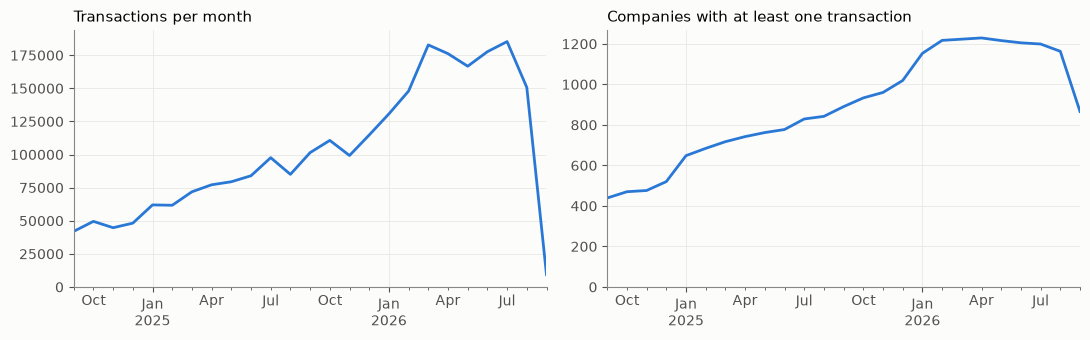

In [ ]:
tx["month"] = tx.date.dt.to_period("M")
print("date range:", tx.date.min(), "->", tx.date.max())
print("status:", tx.status.value_counts(dropna=False).to_dict())
print("exchange_rate != 1:", (tx.exchange_rate != 1).mean().round(4))

monthly = tx.groupby("month").agg(
    n=("amount", "size"),
    companies=("company_id", "nunique"),
    inflow=("amount", lambda s: s[s > 0].sum()),
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
monthly.n.plot(ax=axes[0], color=BLUE, lw=2)
axes[0].set(title="Transactions per month", xlabel="", ylim=0)
monthly.companies.plot(ax=axes[1], color=BLUE, lw=2)
axes[1].set(title="Companies with at least one transaction", xlabel="", ylim=0)
plt.tight_layout()
monthly.T

companies with >= 12 months: 0.71
groups with >= 12 months:    0.67
groups with >= 24 months:    0.36


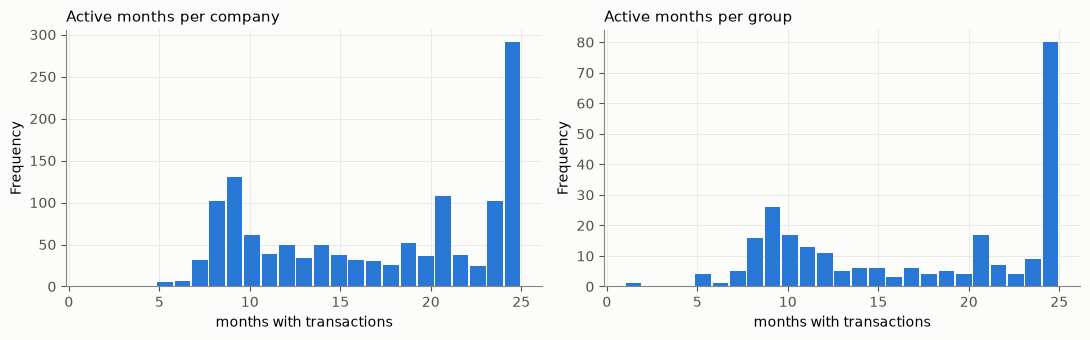

In [ ]:
# How much history does each company and each group really have?
co_months = tx.groupby("company_id").month.nunique()
tx = tx.merge(companies[["company_id", "group_id"]], on="company_id")
gr_months = tx.groupby("group_id").month.nunique()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
co_months.plot.hist(bins=25, ax=axes[0], color=BLUE, rwidth=0.9)
axes[0].set(title="Active months per company", xlabel="months with transactions")
gr_months.plot.hist(bins=25, ax=axes[1], color=BLUE, rwidth=0.9)
axes[1].set(title="Active months per group", xlabel="months with transactions")
plt.tight_layout()
print("companies with >= 12 months:", (co_months >= 12).mean().round(2))
print("groups with >= 12 months:   ", (gr_months >= 12).mean().round(2))
print("groups with >= 24 months:   ", (gr_months >= 24).mean().round(2))

In [ ]:
# Do companies enter late, or do they also go silent before the end?
span = tx.groupby("company_id").month.agg(["min", "max"])
print("first active month:\n", span["min"].value_counts().sort_index().to_string())
print("\nlast active month:\n", span["max"].value_counts().sort_index().tail(8).to_string())

first active month:
 min
2024-09    439
2024-10     38
2024-11     10
2024-12     43
2025-01    128
2025-02     40
2025-03     40
2025-04     22
2025-05     25
2025-06     20
2025-07     42
2025-08     37
2025-09     33
2025-10     46
2025-11     38
2025-12     64
2026-01    132
2026-02     78
2026-03      7
2026-04      1
2026-05      3
Freq: M

last active month:
 max
2026-02      6
2026-03      5
2026-04     11
2026-05     12
2026-06     16
2026-07     44
2026-08    299
2026-09    866
Freq: M


In [ ]:
cat = tx.groupby("category", dropna=False).amount.agg(
    n="size", total="sum", median="median", share_inflow=lambda s: (s > 0).mean()
)
cat.sort_values("n", ascending=False)

,n,total,median,share_inflow
category,,,,
-,635530,"12,986,541,312.76",-26.98,0.35
collection,567417,"89,957,875,511.67",859.54,1.00
payment,362276,"-89,271,682,594.27",-857.53,0.00
utility,259430,"-18,755,662,971.79",-147.91,0.00
fee,179500,"-361,961,047.17",-5.40,0.00
transfer,152102,"21,566,935,804.17",162.76,0.60
bulk_collection,65492,"458,301,463.76",682.65,1.00
tax,55904,"-2,126,776,101.97",-392.69,0.02
cash_settlement,48280,"10,303,239,864.13","1,351.25",1.00


Category `-` (uncategorized) is the largest bucket, and `counterparty_id` is 90% empty on
transactions. Amounts are heavy-tailed:

count        2,556,437.00
mean             3,340.44
std          7,589,587.47
min     -3,069,784,469.83
1%            -585,660.17
5%             -32,323.86
50%                 -9.18
95%             27,752.73
99%            480,000.00
max      3,100,000,000.00


[Text(0.0, 1.0, 'log10 |amount| of transactions'),
 Text(0.5, 0, 'log10 EUR-ish (mixed currencies)')]

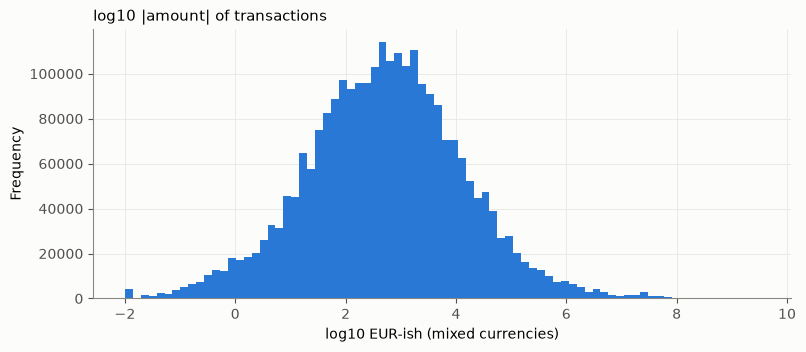

In [ ]:
print(tx.amount.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())
ax = np.log10(tx.amount.abs().clip(lower=0.01)).plot.hist(bins=80, color=BLUE)
ax.set(title="log10 |amount| of transactions", xlabel="log10 EUR-ish (mixed currencies)")

In [ ]:
# Transfers between own accounts inflate both inflow and outflow. How big are they?
flows = tx.assign(kind=np.where(tx.amount > 0, "inflow", "outflow")).pivot_table(
    index="category", columns="kind", values="amount", aggfunc="sum"
)
(flows / flows.sum()).sort_values("inflow", ascending=False).head(10)

kind,inflow,outflow
category,,
-,0.41,0.37
collection,0.32,0.00
transfer,0.22,0.15
cash_settlement,0.04,-0.00
payment_refund,0.01,0.00
investment_return,0.00,NaN
bulk_collection,0.00,NaN
tax,0.00,0.01
pos_settlement,0.00,-0.00


## 5. Invoices

In [ ]:
print("companies with invoices:", inv.company_id.nunique(), "of", len(companies))
inv = inv.merge(companies[["company_id", "group_id"]], on="company_id")
print("groups with invoices:   ", inv.group_id.nunique(), "of", len(groups))
print("\n", inv.document_type.value_counts().to_string())
print("\n", inv.status.value_counts().to_string())

companies with invoices: 785 of 1286
groups with invoices:    167 of 250

 document_type
invoice            760406
paymentDocument     53761
note                38154
deposit             21390
invoiceGroup        13775
deliveryNote         6380
refund               2018
purchaseOrder        1259
other                 739
cheque                 12

 status
paid                   660299
overdue                192556
pending                 29717
cancel                  13699
payment_in_progress      1216
paymentOrder              406
shipped                     1


In [ ]:
# Sign: positive = issued (receivable), negative = received (payable)?
inv["side"] = np.where(inv.amount > 0, "positive", "negative")
print(
    inv.groupby("side").agg(
        n=("amount", "size"), total=("amount", "sum"), counterparties=("counterparty_id", "nunique")
    )
)
pd.crosstab(inv.status, inv.side, normalize="columns").round(3)

               n               total  counterparties
side                                                
negative  531228 -126,798,883,935.07           79548
positive  366666  150,917,279,590.00           63814


side,negative,positive
status,,
cancel,0.02,0.01
overdue,0.17,0.27
paid,0.77,0.68
paymentOrder,0.00,0.00
payment_in_progress,0.00,0.00
pending,0.03,0.04
shipped,0.00,0.00


issued outside the 24 month window: 0.000658206870744249


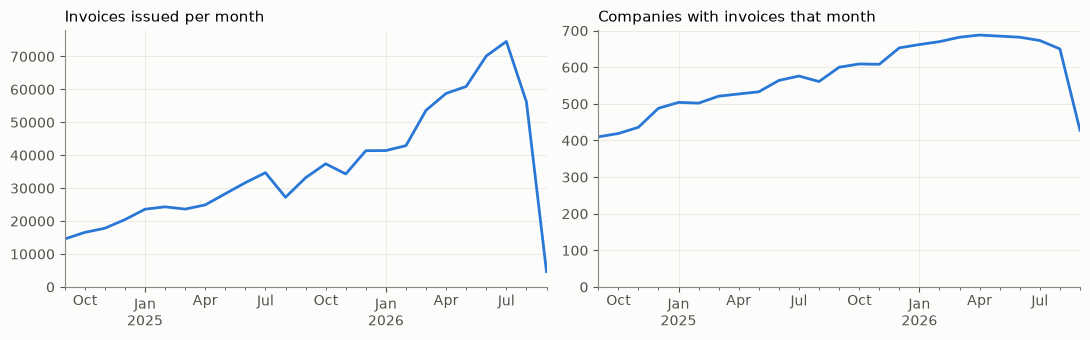

In [ ]:
inv["month"] = inv.issuance_date.dt.to_period("M")
in_window = inv[(inv.issuance_date >= "2024-09-01") & (inv.issuance_date <= "2026-09-01")]
print("issued outside the 24 month window:", 1 - len(in_window) / len(inv))
m = in_window.groupby("month").agg(n=("amount", "size"), companies=("company_id", "nunique"))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
m.n.plot(ax=axes[0], color=BLUE, lw=2)
axes[0].set(title="Invoices issued per month", xlabel="", ylim=0)
m.companies.plot(ax=axes[1], color=BLUE, lw=2)
axes[1].set(title="Companies with invoices that month", xlabel="", ylim=0)
plt.tight_layout()

### Payment behaviour
`payment_date` is never null, even for unpaid invoices. What does it hold there?

In [ ]:
unpaid = inv[inv.status.isin(["overdue", "pending"])]
print("unpaid: payment_date == due_date:", (unpaid.payment_date == unpaid.due_date).mean().round(3))
print(
    "unpaid: payment_date in the future (> 2026-09-01):",
    (unpaid.payment_date > "2026-09-01").mean().round(3),
)
print(
    "paid:   pending_amount == 0:", (inv[inv.status == "paid"].pending_amount == 0).mean().round(3)
)

unpaid: payment_date == due_date: 0.966
unpaid: payment_date in the future (> 2026-09-01): 0.142
paid:   pending_amount == 0: 1.0


          days_late         term
count    554,559.00   554,559.00
mean           5.07        29.66
std        2,860.73     3,732.61
min   -1,826,163.00    -9,247.00
1%           -57.00        -8.00
5%           -22.00         0.00
25%            0.00         0.00
50%            0.00        13.00
75%            6.00        30.00
95%           65.00        77.00
99%          211.00       113.00
max       13,149.00 1,826,211.00


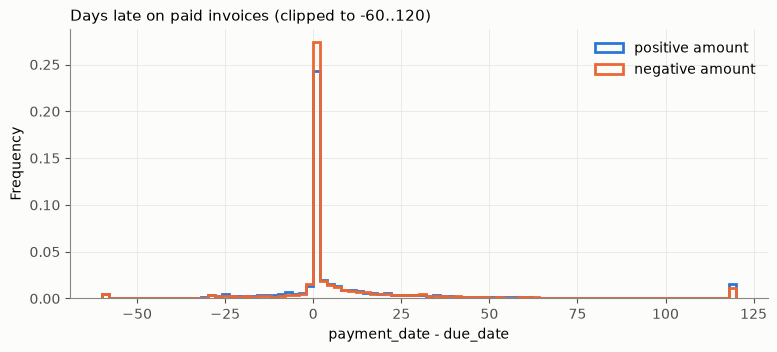

In [ ]:
paid = inv[(inv.status == "paid") & inv.document_type.eq("invoice")].copy()
paid["days_late"] = (paid.payment_date - paid.due_date).dt.days
paid["term"] = (paid.due_date - paid.issuance_date).dt.days
print(
    paid[["days_late", "term"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .to_string()
)

fig, ax = plt.subplots()
for side, color in [("positive", BLUE), ("negative", ORANGE)]:
    paid.loc[paid.side == side, "days_late"].clip(-60, 120).plot.hist(
        bins=90, ax=ax, histtype="step", lw=2, color=color, label=f"{side} amount", density=True
    )
ax.set(title="Days late on paid invoices (clipped to -60..120)", xlabel="payment_date - due_date")
ax.legend(frameon=False)

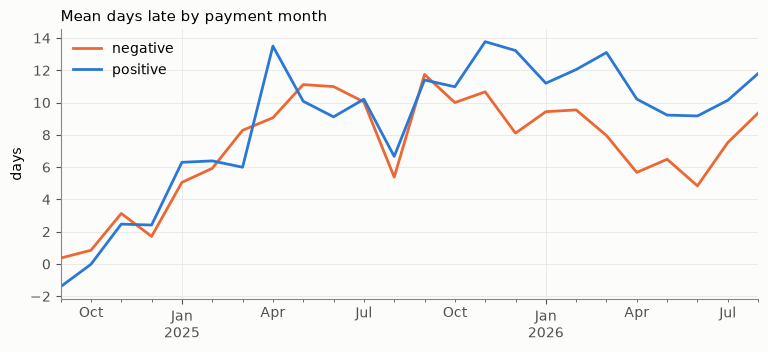

In [ ]:
# Payment delay over time, split by side: the raw material for DSO / DPO trends.
paid["pay_month"] = paid.payment_date.dt.to_period("M")
w = paid[
    (paid.payment_date >= "2024-09-01")
    & (paid.payment_date <= "2026-08-31")
    & paid.days_late.between(-90, 365)
]
trend = w.pivot_table(index="pay_month", columns="side", values="days_late", aggfunc="mean")
ax = trend.plot(lw=2, color=[ORANGE, BLUE])
ax.set(title="Mean days late by payment month", xlabel="", ylabel="days")
ax.legend(frameon=False)

In [ ]:
# Overdue stock at the snapshot: how old is it, and how concentrated?
ov = inv[inv.status == "overdue"].assign(
    age=lambda x: (pd.Timestamp("2026-09-01") - x.due_date).dt.days
)
print(ov.age.describe(percentiles=[0.05, 0.5, 0.95]).to_string())
by_group = ov.groupby(["group_id", "side"]).pending_amount.sum().unstack(fill_value=0)
print("\ngroups with overdue invoices:", len(by_group))
by_group.describe()

count   192,554.00
mean        247.37
std         219.23
min        -242.00
5%            2.00
50%         185.00
95%         623.00
max       9,436.00

groups with overdue invoices: 167


side,negative,positive
count,167.00,167.00
mean,"-57,315,310.44","93,928,358.44"
std,"341,628,396.58","848,557,138.19"
min,"-3,308,308,957.07",0.00
25%,"-4,647,817.59","268,599.04"
50%,"-1,013,333.58","1,368,117.70"
75%,"-237,902.05","5,992,412.95"
max,0.00,"10,769,833,259.35"


## 6. Balances (snapshot at 1 Sep 2026)

In [ ]:
b = bal.merge(pd.concat([bank, debt])[["product_id", "type"]], on="product_id", how="left")
print("products without a balance row:", len(bank) + len(debt) - len(bal))
b.groupby("type").balance.agg(["size", "median", "min", "max", lambda s: (s < 0).mean()]).rename(
    columns={"<lambda_0>": "share_negative"}
)

products without a balance row: 230


,size,median,min,max,share_negative
type,,,,,
card,794,0.00,"-31,396.66","1,000,000.00",0.34
checking,4647,"6,781.88","-999,999,999.00","99,999,990,850.00",0.02
confirming,227,0.00,"-8,774,588.25","1,258,976.00",0.32
expensesPlatform,23,"7,175.13",0.00,"50,000.00",0.00
factoring,23,0.00,"-3,113,196.00","7,984,791.79",0.26
guarantee,149,"-39,583.00","-13,812,212.00",223.52,0.89
investment,185,"61,779.19","-12,000.00","35,000,000.00",0.01
leasing,176,"-33,616.75","-9,156,115.19",0.00,0.90
lineofcomex,19,0.00,"-2,399,117.33","23,590.00",0.37


In [ ]:
# Can we rebuild a monthly balance history by walking transactions back from the snapshot?
# balance(end of month m) = snapshot - sum(transactions after m)
chk = bank[bank.type == "checking"].product_id
t = tx[tx.product_id.isin(chk)]
flow = t.groupby(["product_id", "month"]).amount.sum().unstack(fill_value=0).sort_index(axis=1)
snap = bal.set_index("product_id").balance.reindex(flow.index)
after = flow.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1].shift(-1, axis=1).fillna(0)
hist = (-after).add(snap, axis=0)
print("checking accounts with snapshot and transactions:", snap.notna().sum())
print(
    "share of account-months with negative rebuilt balance:",
    (hist.dropna() < 0).mean().mean().round(3),
)
print("share of accounts negative at snapshot:               ", (snap < 0).mean().round(3))

checking accounts with snapshot and transactions: 4094
share of account-months with negative rebuilt balance: 0.098
share of accounts negative at snapshot:                0.021


If the rebuilt balances go negative far more often than the snapshot does, the transaction
feed is incomplete (or amounts are in mixed currencies) and balance history cannot be trusted
as a level. Its trend may still be usable.

## 7. Group monthly panel: first look at trajectories

In [ ]:
# Drop own-account transfers and the partial month of Sep 2026.
core = tx[(tx.category != "transfer") & (tx.month < "2026-09")]
panel = core.groupby(["group_id", "month"]).agg(
    inflow=("amount", lambda s: s[s > 0].sum()),
    outflow=("amount", lambda s: -s[s < 0].sum()),
    n=("amount", "size"),
)
panel["net"] = panel.inflow - panel.outflow
panel["coverage"] = panel.inflow / panel.outflow.replace(0, np.nan)
print(panel.coverage.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

count     4,092.00
mean        156.78
std       3,732.14
min           0.00
5%            0.14
25%           0.73
50%           0.96
75%           1.18
95%           2.73
max     150,715.90


groups shrinking > 30%: 39 | growing > 30%: 45


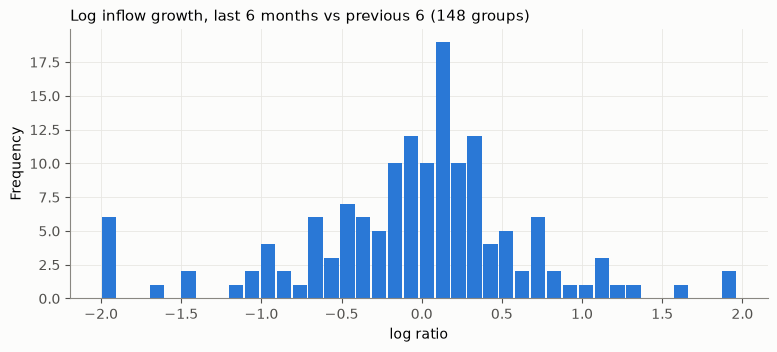

In [ ]:
# Trend of inflows: last 6 full months vs the 6 before, for groups with enough history.
wide = panel.inflow.unstack("month").loc[:, "2025-09":"2026-08"]
full = wide.dropna()
growth = np.log(full.iloc[:, 6:].sum(axis=1) / full.iloc[:, :6].sum(axis=1)).replace(
    [np.inf, -np.inf], np.nan
)
ax = growth.clip(-2, 2).plot.hist(bins=40, color=BLUE, rwidth=0.9)
ax.set(
    title=f"Log inflow growth, last 6 months vs previous 6 ({len(full)} groups)", xlabel="log ratio"
)
print(
    "groups shrinking > 30%:",
    (growth < np.log(0.7)).sum(),
    "| growing > 30%:",
    (growth > np.log(1.3)).sum(),
)

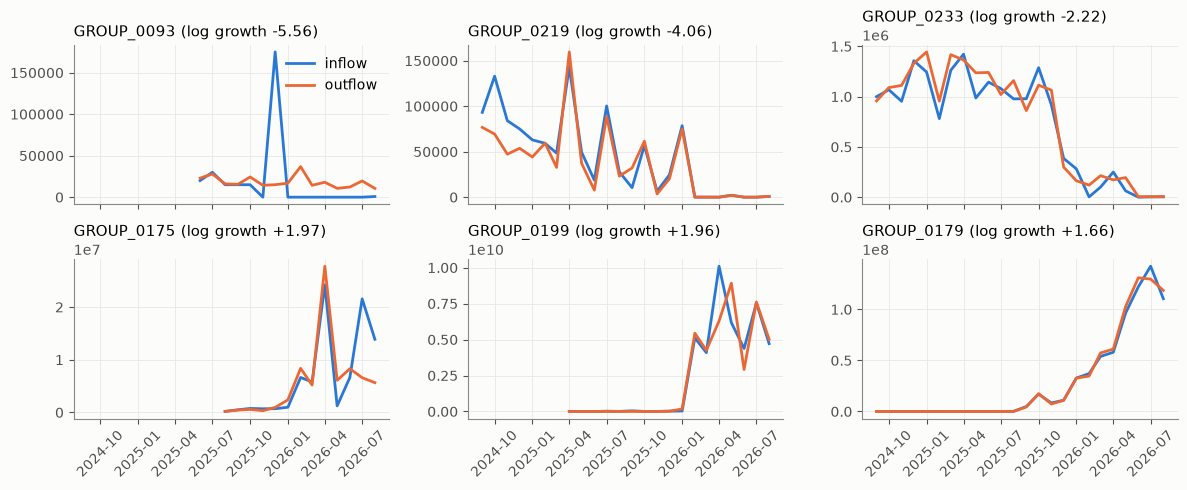

In [ ]:
# Small multiples: six groups from each tail of the growth distribution.
pick = list(growth.nsmallest(3).index) + list(growth.nlargest(3).index)
fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
for ax, g in zip(axes.flat, pick, strict=True):
    s = panel.loc[g]
    x = s.index.to_timestamp()
    ax.plot(x, s.inflow, color=BLUE, lw=2, label="inflow")
    ax.plot(x, s.outflow, color=ORANGE, lw=2, label="outflow")
    ax.set_title(f"{g} (log growth {growth[g]:+.2f})")
    ax.tick_params(axis="x", rotation=45)
axes[0, 0].legend(frameon=False)
plt.tight_layout()

The "growing" groups look like step changes, not organic growth. Check whether the group
perimeter (number of companies reporting) changes at the same time.

In [ ]:
n_active = core.groupby(["group_id", "month"]).company_id.nunique().unstack("month")
print(n_active.loc[pick, "2025-03":"2026-08":3].to_string())
changed = (n_active.max(axis=1) > n_active.bfill(axis=1).iloc[:, 0]).mean()
print(f"\ngroups whose number of reporting companies grows inside the window: {changed:.0%}")

month       2025-03  2025-06  2025-09  2025-12  2026-03  2026-06
group_id                                                        
GROUP_0093      NaN     1.00     1.00     1.00     1.00     1.00
GROUP_0219     1.00     1.00     1.00     1.00     1.00     1.00
GROUP_0233     1.00     1.00     1.00     1.00     1.00     1.00
GROUP_0175      NaN      NaN     3.00     6.00     6.00     6.00
GROUP_0199      NaN     1.00     4.00     7.00    11.00    11.00
GROUP_0179     1.00     1.00     4.00     6.00     7.00     7.00

groups whose number of reporting companies grows inside the window: 44%


## 8. Findings

**Shape of the problem**
- No label in any file. The score is unsupervised or built on proxy outcomes we define
  (overdue build-up, inflow collapse, going silent, debt utilization).
- Panel is unbalanced: 439 companies report in Sep 2024, about 1,200 by 2026. Only 36% of
  groups have all 24 months, 67% have 12 or more. Entry is staggered (waves in Sep 2024,
  Jan 2025, Jan 2026); history is often backfilled before `created_at`, so use the first
  transaction, not `created_at`, as the start of observation.
- Group perimeter changes: new companies get connected mid-window, which looks like growth in
  group totals. Score on a fixed perimeter or per company, then aggregate.
- A few companies go silent before Aug 2026 (about 50 stop by Jun 2026): candidate distress proxy.
- Sep 2026 is a partial month (one day). Drop it from monthly features.

**Transactions** (2.56M rows, all 1,286 companies)
- 25% are category `-`, carrying about 40% of the money both ways. `transfer` is another
  15 to 22%: exclude it from operating flows.
- Useful named flows: `collection`, `payment`, `salary`, `social_security`, `tax`,
  `debt_repayment`, `interest_charge`, `fee`, `collection_refund`.
- `counterparty_id` is 90% empty here, so customer concentration has to come from invoices.
- Amounts are in account currency (4% have fx != 1) and extremely heavy-tailed (single
  movements of 3e9). Use ratios, logs and robust statistics, never raw sums across groups.

**Invoices** (898K rows, only 785 companies and 167 of 250 groups)
- Any invoice feature needs a missing-indicator: a third of groups have none.
- Sign: positive looks like receivables, negative like payables. Confirm with the organizers.
- `payment_date` is never null: for unpaid invoices it equals `due_date` (expected date), so it
  is only a real payment date when `status == "paid"`.
- `status` and `pending_amount` are the state at extraction, i.e. month-24 information.
  For month t, rebuild "open and past due at t" from issuance, due and paid dates only.
- 21% of invoices are overdue, median age 185 days: the overdue stock is large and old.
- Date garbage exists (terms of 1.8M days, year-1 style dates): clip to a sane range.
- Invoice volume grows with onboarding, so compare rates, not counts.

**Products and balances**
- Debt is stored negative; 145 products have positive outstanding and 169 lack `granted`.
  378 companies have debt. Only 87 products have a schedule.
- Credit lines, confirming and factoring report `liquidity`, so utilization is computable for them.
- Balances contain sentinels (-999,999,999 and 99,999,990,850): filter before use.
- Rebuilding balance history from the snapshot gives negative checking balances in 10% of
  account-months vs 2% at the snapshot: the feed is not complete enough to trust levels.

**Candidate drivers for the score**
1. Operating coverage: inflow / outflow excluding transfers, 3 month rolling.
2. Inflow trend and volatility, per company, on a fixed perimeter.
3. Collection delay (DSO-like) and its trend; share of receivables past due at t.
4. Own payment delay (DPO-like): paying suppliers later is an early stress signal.
5. Fixed-cost burden: salary + social security + tax over inflow; missed payroll months.
6. Debt service over inflow; fees, interest charges and `collection_refund` (returned receipts) rates.
7. Activity: transaction count trend and silence.